# Reading profiles

An image-based profiling pipeline hands you a table: one row per well or per cell, a few hundred columns of
CellProfiler measurements, and some metadata columns mixed in among them.
{func}`~mantispy.io.read_profiles` turns one or many of those tables into an {class}`~anndata.AnnData`.
It splits the measurements from the metadata and annotates what each feature name encodes.

In [1]:
import mantispy as mt

## A dataset

{mod}`mantispy.ds` downloads whole accessions from the
[Cell Painting Gallery](https://github.com/broadinstitute/cellpainting-gallery), so there is something real to
read.
This one is kinase inhibitors at a range of doses, eight plates of it.

In [2]:
adata = mt.ds.pki()
adata

  0%|                                              | 0.00/1.33M [00:00<?, ?B/s]

  0%|                                              | 0.00/1.33M [00:00<?, ?B/s]

  0%|                                              | 0.00/1.32M [00:00<?, ?B/s]

  0%|                                              | 0.00/1.32M [00:00<?, ?B/s]

  0%|                                              | 0.00/1.32M [00:00<?, ?B/s]

  0%|                                              | 0.00/1.32M [00:00<?, ?B/s]

  0%|                                              | 0.00/1.32M [00:00<?, ?B/s]

  0%|                                              | 0.00/1.32M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 3072 × 1061
    obs: 'plate_map_name', 'broad_sample', 'mg_per_ml', 'mmoles_per_liter', 'solvent', 'Plate', 'Well', 'Site_Count', 'Count_Cells', 'Count_CellsIncludingEdges', 'Count_Cytoplasm', 'Count_Nuclei', 'Count_NucleiIncludingEdges', 'Object_Count', 'Barcode', 'Supplier', 'Supplier_Catalog', 'moa', 'pert_type', 'control_type'
    var: 'compartment', 'family', 'channel', 'channel_2', 'n_channels'
    layers: None (.X)

Numeric columns became the feature matrix and everything else became `obs`.
The `Metadata_` prefix is stripped, so the compound of each well reads as `broad_sample` and its dose as
`mmoles_per_liter`.

In [3]:
adata.obs.head()

,plate_map_name,broad_sample,mg_per_ml,mmoles_per_liter,solvent,Plate,Well,Site_Count,Count_Cells,Count_CellsIncludingEdges,Count_Cytoplasm,Count_Nuclei,Count_NucleiIncludingEdges,Object_Count,Barcode,Supplier,Supplier_Catalog,moa,pert_type,control_type
observation,,,,,,,,,,,,,,,,,,,,
BR00122970:A01,C-7210-01-CMP-014,<NA>,NaN,NaN,DMSO,BR00122970,A01,9,1758,1890,1758,1758,1890,1758,<NA>,<NA>,DMSO,<NA>,control,negcon
BR00122970:A02,C-7210-01-CMP-014,<NA>,NaN,NaN,DMSO,BR00122970,A02,9,1941,2137,1941,1941,2137,1941,<NA>,<NA>,DMSO,<NA>,control,negcon
BR00122970:A03,C-7210-01-CMP-014,<NA>,NaN,NaN,DMSO,BR00122970,A03,9,1840,2007,1840,1840,2007,1840,<NA>,<NA>,DMSO,<NA>,control,negcon
BR00122970:A04,C-7210-01-CMP-014,<NA>,NaN,NaN,DMSO,BR00122970,A04,9,1869,2027,1869,1869,2027,1869,<NA>,<NA>,DMSO,<NA>,control,negcon
BR00122970:A05,C-7210-01-CMP-014,<NA>,NaN,NaN,DMSO,BR00122970,A05,9,2165,2369,2165,2165,2369,2165,<NA>,<NA>,DMSO,<NA>,control,negcon


Feature selection ran per plate, so the eight plates did not agree on their columns and were read down to the
features they share.
That is `on_column_mismatch="intersect"`; the default is to raise instead, so a mismatch is never silent.

In [4]:
adata.obs.groupby("Plate", observed=True).size()

Plate
BR00122970    384
BR00122971    384
BR00122972    384
BR00122973    384
BR00122974    384
BR00122975    384
BR00122977    384
BR00122978    384
dtype: int64

## What a feature name says

CellProfiler names a feature `<compartment>_<family>_<measurement>[_<channel>]`, and
{func}`~mantispy.io.read_profiles` pulls that apart into `var`.
`Correlation` features measure colocalization between a pair of channels and carry two.
`AreaShape` is geometry and carries none.

In [5]:
adata.var.head()

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Image_Granularity_10_AGP,image,granularity,agp,NaN,1
Image_Granularity_10_BFHigh,image,granularity,brightfield_high,NaN,1
Image_Granularity_10_BFLow,image,granularity,brightfield_low,NaN,1
Image_Granularity_10_Brightfield,image,granularity,brightfield,NaN,1
Image_Granularity_10_Mito,image,granularity,mito,NaN,1


In [6]:
adata.var.groupby(["compartment", "family"], observed=True).size().sort_values(ascending=False).head(10)

compartment  family            
image        granularity           84
nuclei       texture               79
cytoplasm    correlation           78
cells        correlation           66
nuclei       granularity           66
cytoplasm    texture               65
             granularity           63
             radialdistribution    58
nuclei       correlation           56
cells        radialdistribution    53
dtype: int64

A slice of the measurements is then a query on `var`, not a regex on the names:

In [7]:
dna_intensity = adata[:, (adata.var["channel"] == "dna") & (adata.var["family"] == "intensity")]
dna_intensity.shape

(3072, 13)

## Reading your own files

The remaining arguments cover what has differed between datasets:

```python
adata = mt.io.read_profiles(
    sorted(Path("profiles").glob("*/*.parquet")),
    sentinels=-999,                          # values standing for missing, replaced with NaN
    index_columns=("Plate", "Well"),         # joined with ":" into the observation index
    metadata_columns=("ImageNumber",),       # numeric columns that are not features
    path_columns={"Metadata_Batch": 2},      # metadata read off the file path
    on_column_mismatch="intersect",
)
```

`path_columns` maps a column name to how many directories up from the file to read the name of.
That is how a batch or a plate that exists only in the directory layout gets into `obs`.

## A first look

The profiles are ready for the rest of the scverse ecosystem at this point.

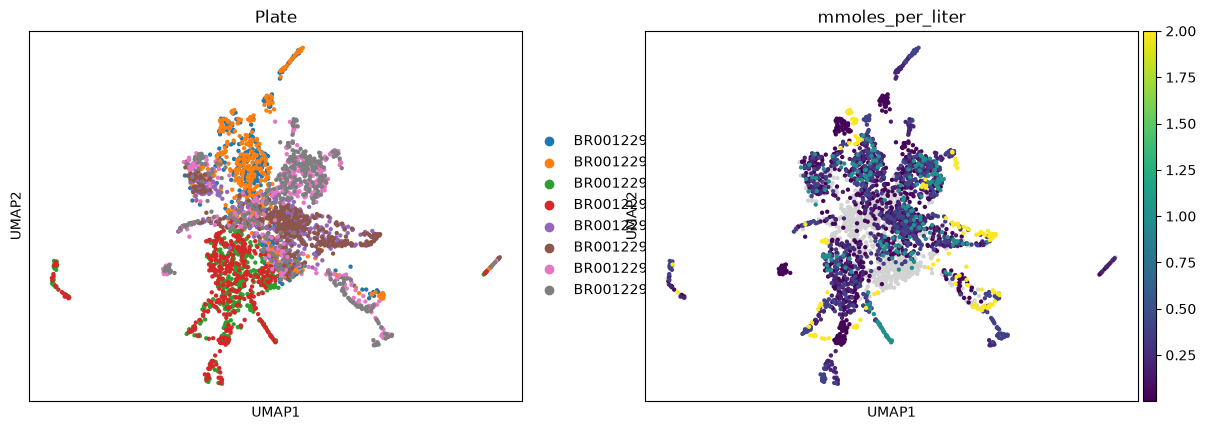

In [8]:
import scanpy as sc

sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["Plate", "mmoles_per_liter"], ncols=2)

The plates separate.
That is the batch effect a real analysis has to correct before reading anything into the rest of the picture.